In [70]:
import re
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Data/customer_reviews_clean.csv")
df.head()

,id,asins,product_name,title,text,rating,do_recommend,keys,clean_text,n_words,sentiment
0,AVqkIhwDv8e3D1O-lebb,B01AHB9CN2,all new fire hd 8 tablet 8 hd display wi fi 16...,Kindle,This product so far has not disappointed. My c...,5,1.0,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",kindle . this product so far has not disappoin...,29,positive
1,AVqkIhwDv8e3D1O-lebb,B01AHB9CN2,all new fire hd 8 tablet 8 hd display wi fi 16...,very fast,great for beginner or experienced person. Boug...,5,1.0,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",very fast . great for beginner or experienced ...,17,positive
2,AVqkIhwDv8e3D1O-lebb,B01AHB9CN2,all new fire hd 8 tablet 8 hd display wi fi 16...,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,5,1.0,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",beginner tablet for our 9 year old son. . inex...,35,positive
3,AVqkIhwDv8e3D1O-lebb,B01AHB9CN2,all new fire hd 8 tablet 8 hd display wi fi 16...,Good!!!,I've had my Fire HD 8 two weeks now and I love...,4,1.0,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",good!! . i've had my fire hd 8 two weeks now a...,120,positive
4,AVqkIhwDv8e3D1O-lebb,B01AHB9CN2,all new fire hd 8 tablet 8 hd display wi fi 16...,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,5,1.0,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",fantastic tablet for kids . i bought this for ...,122,positive


In [71]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)

import os
import pandas as pd

print(os.listdir(path))  # see which files are there
df_original = pd.read_csv(os.path.join(path, "1429_1.csv"), usecols=["id", "categories"], low_memory=False)

# One categories value per product
cat_by_id = df_original.drop_duplicates("id").set_index("id")["categories"]

# Add it back to your cleaned data
df["categories"] = df["id"].map(cat_by_id)

print(df["categories"].isna().sum())   
df.dtypes

Path to dataset files: C:\Users\PCACER\.cache\kagglehub\datasets\datafiniti\consumer-reviews-of-amazon-products\versions\5
['1429_1.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv']
0


id                  str
asins               str
product_name        str
title               str
text                str
rating            int64
do_recommend    float64
keys                str
clean_text          str
n_words           int64
sentiment           str
categories          str
dtype: object

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

products = df.drop_duplicates("product_name")[["product_name", "categories"]]
text = products["product_name"] + " " + products["categories"]   # name + categories

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(text)     # one row of numbers per product

print(X.shape)   # (number of products, number of words)

(38, 226)


In [74]:
from sklearn.cluster import KMeans

from sklearn.cluster import KMeans
products["n_reviews"] = products["product_name"].map(df["product_name"].value_counts())

kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
products["cluster"] = kmeans.fit_predict(X)

for number, group in products.groupby("cluster"):
    print(f"\n--- cluster {number} ({len(group)} products)")
    for row in group.sort_values("n_reviews", ascending=False).itertuples():
        print(f"{row.n_reviews:>6}  {row.product_name[:70]}")


--- cluster 0 (8 products)
  3176  amazon kindle paper white ebook reader 4 gb 6 monochrome paper white t
   580  kindle voyage e reader 6 high resolution display 300 ppi with adaptive
   212  all new kind lee reader black 6 glare free touchscreen display wi fi i
    67  kindle oasis e reader with leather charging cover merlot 6 high resolu
    51  amazon kindle voyage 4 gb wi fi 3 g black
    30  kindle paper white e reader white 6 high resolution display 300 ppi wi
    15  kindle paper white
     6  kindle oasis e reader with leather charging cover black 6 high resolut

--- cluster 1 (13 products)
 10965  fire tablet 7 display wi fi 8 gb includes special offers magenta
  2814  all new fire hd 8 tablet 8 hd display wi fi 16 gb includes special off
  1685  fire kids edition tablet 7 display wi fi 16 gb green kid proof case
  1038  brand new amazon kindle fire 16 gb 7 ips display table twi fi 16 gb bl
   372  fire tablet 7 display wi fi 8 gb includes special offers black
   270  amazon

In [75]:
cluster_names = {
    0: "Kindle",
    1: "Tablets",
    2: "Echo & Smart Speakers",
    3: "Fire TV",
    4: "Chargers, Cables",
}
products["category"] = products["cluster"].map(cluster_names)

# Reading the printout in 3.3 shows one mistake: "Kindle Fire 16 GB Blue" is a Fire tablet, not an e-reader.
# Moving a wrong product by hand is a normal step after you read the clusters.
products.loc[products["product_name"].str.contains("Kindle Fire 16 GB"), "category"] = "Fire Tablets"

products[["product_name", "category"]].sort_values("category").sample(36)

,product_name,category
20608,kindle voyage e reader 6 high resolution displ...,Kindle
14702,certified refurbished amazon fire tv previous ...,Fire TV
34604,amazon kindle fire 5 ft usb to micro usb cable...,"Chargers, Cables"
2886,all new fire hd 8 tablet 8 hd display wi fi 32...,Tablets
21546,fire tablet 7 display wi fi 8 gb includes spec...,Tablets
28545,amazon 9 w power fast official oem usb charger...,"Chargers, Cables"
0,all new fire hd 8 tablet 8 hd display wi fi 16...,Tablets
21242,amazon echo fire tv power adapter,"Chargers, Cables"
14636,kindle oasis e reader with leather charging co...,Kindle
28618,amazon fire hd 6 standing protective case 4 th...,"Chargers, Cables"


category
Tablets                  17596
Echo & Smart Speakers     7262
Fire TV                   5068
Kindle                    4137
Chargers, Cables           562
Name: count, dtype: int64
sentiment              negative  neutral  positive
category                                          
Chargers, Cables           12.6      5.5      81.9
Echo & Smart Speakers       1.6      3.6      94.8
Fire TV                     1.5      2.7      95.8
Kindle                      1.0      2.1      96.9
Tablets                     2.9      5.6      91.5


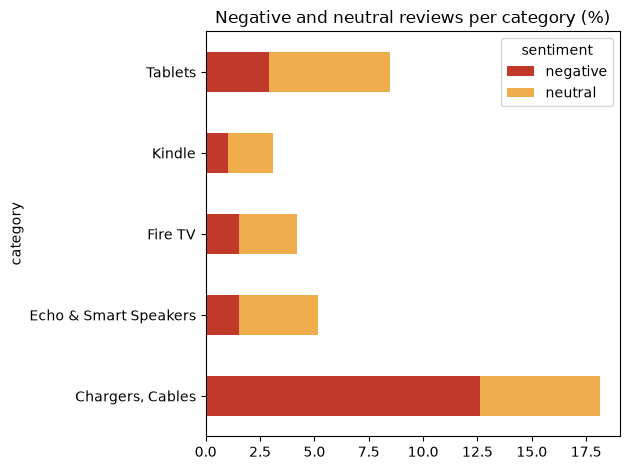

In [77]:
df["cluster"] = df["product_name"].map(products.set_index("product_name")["cluster"])
df["category"] = df["cluster"].map(cluster_names)
print(df["category"].value_counts())

products.to_csv("../Reports/product_categories.csv", index=False)

share = pd.crosstab(df["category"], df["sentiment"], normalize="index") * 100
print(share.round(1))
share[["negative", "neutral"]].plot(kind="barh", stacked=True, color=["#c0392b", "#f0ad4e"])
plt.title("Negative and neutral reviews per category (%)")
plt.tight_layout()
plt.savefig("../Reports/03_sentiment_by_category.png")
plt.show()

In [78]:
df.dtypes

id                  str
asins               str
product_name        str
title               str
text                str
rating            int64
do_recommend    float64
keys                str
clean_text          str
n_words           int64
sentiment           str
categories          str
cluster           int32
category            str
dtype: object

In [79]:
df.sample(5)

,id,asins,product_name,title,text,rating,do_recommend,keys,clean_text,n_words,sentiment,categories,cluster,category
34198,AV1YE_muvKc47QAVgpwE,B00U3FPN4U,fire tv streaming media player 2015 model,Great item,Items is very easy and a noob friendly. I love...,5,1.0,"848719057492,amazonfiretv/51454342,amazonfiret...",great item . items is very easy and a noob fri...,15,positive,"Back To College,College Electronics,College Tv...",3,Fire TV
23735,AVpfl8cLLJeJML43AE3S,"B00L9EPT8O,B01E6AO69U",echo white,"Great device, awesome color!!",Echo is a great product that continues to impr...,4,1.0,"echowhite/263039693056,echowhite/152558276095,...","great device, awesome color!! . echo is a grea...",18,positive,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",2,Echo & Smart Speakers
7185,AVphgVaX1cnluZ0-DR74,B018Y229OU,fire tablet 7 display wi fi 8 gb includes spec...,purchased for our grandson - great,"inexpensive, easy to use, good color, light we...",4,1.0,firetablet7displaywifi8gbincludesspecialoffers...,purchased for our grandson great . inexpensive...,14,positive,"Fire Tablets,Tablets,Computers & Tablets,All T...",1,Tablets
14656,AVpftoij1cnluZ0-p5n2,B00IOYAM4I,amazon kindle voyage 4 gb wi fi 3 g black,Outstanding,The Kindle and cover were a gift for my wife. ...,5,1.0,"amazonkindlevoyage4gbwifi3gblack/9301112,amazo...",outstanding . the kindle and cover were a gift...,35,positive,"Computers & Tablets,E-Readers & Accessories,eB...",0,Kindle
12158,AVphgVaX1cnluZ0-DR74,B018Y229OU,fire tablet 7 display wi fi 8 gb includes spec...,daughter loves it,"My daughter loves this tablet, its easy to use...",5,1.0,firetablet7displaywifi8gbincludesspecialoffers...,daughter loves it . my daughter loves this tab...,20,positive,"Fire Tablets,Tablets,Computers & Tablets,All T...",1,Tablets


In [81]:
print(df["category"].value_counts(dropna=False))
print(df.groupby("product_name")["category"].nunique().max())

category
Tablets                  17596
Echo & Smart Speakers     7262
Fire TV                   5068
Kindle                    4137
Chargers, Cables           562
Name: count, dtype: int64
1


In [83]:
df = df.rename(columns={"category": "meta_category"})
df = df.drop(columns=["keys", "n_words"])

In [84]:
print(df.shape)
print(df.isna().sum()[df.isna().sum() > 0])                    # columns with missing values
print(df.groupby("meta_category")["product_name"].nunique())  # products per category
print(df.groupby("meta_category")["sentiment"].value_counts(normalize=True).round(2))

(34625, 12)
title             6
do_recommend    560
dtype: int64
meta_category
Chargers, Cables         10
Echo & Smart Speakers     3
Fire TV                   4
Kindle                    8
Tablets                  13
Name: product_name, dtype: int64
meta_category          sentiment
Chargers, Cables       positive     0.82
                       negative     0.13
                       neutral      0.06
Echo & Smart Speakers  positive     0.95
                       neutral      0.04
                       negative     0.02
Fire TV                positive     0.96
                       neutral      0.03
                       negative     0.02
Kindle                 positive     0.97
                       neutral      0.02
                       negative     0.01
Tablets                positive     0.92
                       neutral      0.06
                       negative     0.03
Name: proportion, dtype: float64


In [85]:
df.to_csv("../Data/reviews_final.csv", index=False)